# Entrenamiento DBSCAN — TreasureFlow ML

Este notebook es **evidencia de entrenamiento** del modelo de clustering geográfico DBSCAN
usado por TreasureFlow ML para agrupar publicaciones de reciclaje en zonas de densidad.

Replica exactamente la lógica matemática del pipeline de producción
(`servidor-ml/training/pca_analysis.py`, `evaluate.py`, `inference/predict.py`), pero corre de
forma standalone, paso a paso, guardando artefactos `.pkl` y figuras `.png` en disco para
incluir en el reporte académico de Minería de Datos.

**Notas metodológicas:**
- DBSCAN es determinístico: no se usa `random_state` porque el algoritmo no tiene componente
  aleatorio (a diferencia de K-Means).
- No hay partición train/test: es un modelo no supervisado, no existen etiquetas verdaderas
  contra las cuales validar un holdout. La evaluación se hace con métricas internas
  (silhouette, % outliers, número de zonas).

## 1. Imports y carga de variables de entorno

In [1]:
import os
import pickle
from pathlib import Path
from datetime import datetime
from math import radians, sin, cos, sqrt, atan2

import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from dotenv import load_dotenv

# El notebook vive en servidor-ml/training/notebooks/, el .env está en servidor-ml/
ENV_PATH = Path.cwd().resolve().parents[1] / ".env"
load_dotenv(dotenv_path=ENV_PATH)

NOTEBOOK_DIR = Path.cwd().resolve()
FIGURES_DIR = NOTEBOOK_DIR / "figures"
ARTIFACTS_DIR = NOTEBOOK_DIR / "artifacts"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f".env cargado desde: {ENV_PATH} (existe: {ENV_PATH.exists()})")

.env cargado desde: /Users/kev29.06/Documents/Cuatrimestre-9/Mineria/Practicas/EDA/treasureflow-ml/servidor-ml/.env (existe: False)


## 2. Conexión a BD Almacén y extracción de `processed_publications`

Se replica el mismo patrón de conexión que `servidor-ml/db/almacen.py:get_connection()`.
Las credenciales se leen únicamente desde variables de entorno — nunca se imprimen en el
notebook (ni siquiera el host) para no exponerlas en el output guardado.

In [5]:
DB_ALMACEN_HOST = os.getenv("DB_ALMACEN_HOST")
DB_ALMACEN_PORT = int(os.getenv("DB_ALMACEN_PORT"))
DB_ALMACEN_NAME = os.getenv("DB_ALMACEN_NAME")
DB_ALMACEN_USER = os.getenv("DB_ALMACEN_USER")
DB_ALMACEN_PASSWORD = os.getenv("DB_ALMACEN_PASSWORD")


def get_connection():
    return psycopg2.connect(
        host=DB_ALMACEN_HOST,
        port=DB_ALMACEN_PORT,
        database=DB_ALMACEN_NAME,
        user=DB_ALMACEN_USER,
        password=DB_ALMACEN_PASSWORD,
    )

# No se filtra por ventana de 90 días (a diferencia de fetch_processed_publications() en
# producción): para el reporte académico se usa toda la tabla ya poblada.
SQL_EXTRACCION = """
    SELECT publication_id, lat, lng, lat_rad, lng_rad, publication_date
    FROM processed_publications
    ORDER BY publication_date DESC
"""

with get_connection() as conn:
    df = pd.read_sql(SQL_EXTRACCION, conn)

if len(df) == 0:
    raise ValueError(
        "La tabla 'processed_publications' está vacía. No se puede entrenar DBSCAN sin "
        "datos reales; no se generan datos falsos como sustituto."
    )

print(f"Shape del DataFrame extraído: {df.shape}")
df.head()

/var/folders/g9/19xq8c0139l8b07rm8vtkywh0000gn/T/ipykernel_3559/2988128490.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL_EXTRACCION, conn)


Shape del DataFrame extraído: (60, 6)


,publication_id,lat,lng,lat_rad,lng_rad,publication_date
0,c0000000-0000-0000-0000-000000000021,16.7512,-93.1089,0.292364,-1.625057,2026-06-22 06:35:11.816372
1,c0000000-0000-0000-0000-000000000001,16.7823,-93.1156,0.292906,-1.625174,2026-06-22 06:35:11.816372
2,c0000000-0000-0000-0000-000000000041,16.7301,-93.1234,0.291995,-1.625310,2026-06-22 06:35:11.816372
3,c0000000-0000-0000-0000-000000000042,16.7297,-93.1228,0.291988,-1.625299,2026-06-20 06:35:11.816372
4,c0000000-0000-0000-0000-000000000022,16.7508,-93.1082,0.292357,-1.625045,2026-06-20 06:35:11.816372


## 3. EDA mínimo de las features de entrada

Verificación rápida de volumen de datos, nulos en coordenadas, y distribución geográfica
cruda (sin clusterizar) antes de aplicar cualquier transformación.

In [6]:
print(f"Total de registros: {len(df)}")
print("\nNulos en lat/lng:")
print(df[["lat", "lng"]].isnull().sum())

Total de registros: 60

Nulos en lat/lng:
lat    0
lng    0
dtype: int64


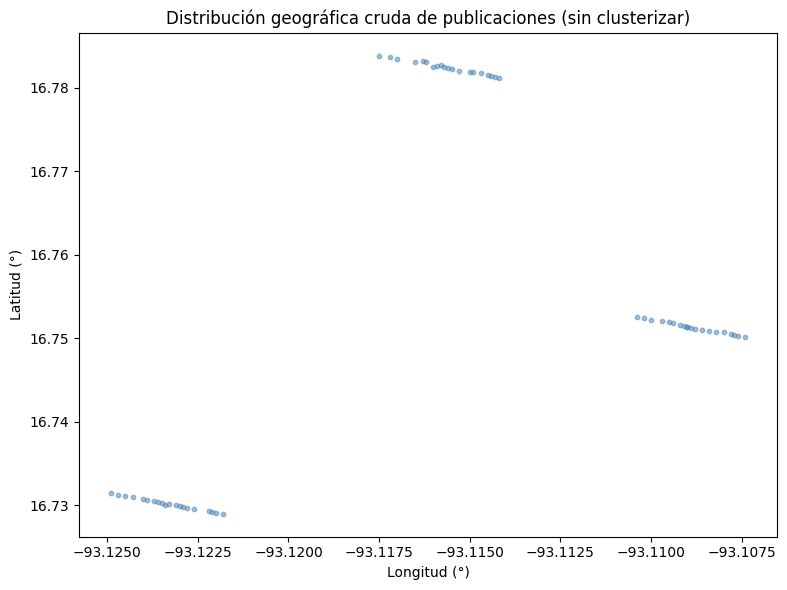

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["lng"], df["lat"], s=10, alpha=0.5, color="steelblue")
ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
ax.set_title("Distribución geográfica cruda de publicaciones (sin clusterizar)")
plt.tight_layout()
plt.show()

## 4. Preprocesamiento: StandardScaler + PCA

Se escalan las coordenadas en **radianes** (`lat_rad`, `lng_rad`) con `StandardScaler` y se
proyectan a 2 componentes con PCA. El PCA aquí no se usa para entrenar DBSCAN (DBSCAN corre
sobre las coordenadas originales en radianes con métrica haversine), sino como **chequeo de
calidad**: si los 2 componentes explican poca varianza, la señal geográfica es ruidosa.

In [8]:
# X: coordenadas en radianes (radianes porque metric='haversine' de sklearn los requiere así)
X = df[["lat_rad", "lng_rad"]].values.astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained_var = float(pca.explained_variance_ratio_.sum())
print(f"Varianza explicada acumulada (PCA, 2 componentes): {explained_var:.4f}")

Varianza explicada acumulada (PCA, 2 componentes): 1.0000


**Umbral de aprobación: `pca_explained_variance >= 0.80`**

Esta celda se completa con el resultado real una vez ejecutado el notebook: si
`explained_var >= 0.80` el PCA confirma que 2 componentes capturan la mayoría de la
estructura geográfica de los datos; si no, la señal está más dispersa de lo esperado y el
modelo resultante debería interpretarse con cautela.

In [9]:
if explained_var >= 0.80:
    print(f"PCA supera el umbral: {explained_var:.4f} >= 0.80")
else:
    print(f"PCA NO supera el umbral: {explained_var:.4f} < 0.80")

PCA supera el umbral: 1.0000 >= 0.80


## 5. Entrenamiento DBSCAN

`eps` se expresa en radianes porque `metric='haversine'` de scikit-learn opera sobre la
esfera terrestre en esa unidad. La conversión metros → radianes es:

```
eps_radianes = eps_metros / radio_tierra_metros
```

donde `radio_tierra_metros = 6 371 000` (radio medio de la Tierra). DBSCAN se ajusta sobre
`X` (las coordenadas en radianes), **no** sobre el espacio proyectado por PCA — el PCA en este
pipeline es solo una métrica de calidad, no una reducción de dimensionalidad para el
clustering.

No se usa `random_state`: DBSCAN es un algoritmo determinístico (el resultado depende solo de
`eps`, `min_samples` y el orden de los datos, no de una semilla aleatoria).

In [10]:
EARTH_RADIUS_M = 6_371_000

ML_EPS_METROS = float(os.getenv("ML_EPS_METROS", "500"))
ML_MIN_SAMPLES = int(os.getenv("ML_MIN_SAMPLES", "4"))

eps_radianes = ML_EPS_METROS / EARTH_RADIUS_M

print(f"eps_metros={ML_EPS_METROS}, eps_radianes={eps_radianes:.10f}, min_samples={ML_MIN_SAMPLES}")

dbscan = DBSCAN(eps=eps_radianes, min_samples=ML_MIN_SAMPLES, metric="haversine")
labels = dbscan.fit_predict(X)

df["cluster_id"] = labels
df[["lat", "lng", "cluster_id"]].head()

eps_metros=500.0, eps_radianes=0.0000784806, min_samples=4


,lat,lng,cluster_id
0,16.7512,-93.1089,0
1,16.7823,-93.1156,1
2,16.7301,-93.1234,2
3,16.7297,-93.1228,2
4,16.7508,-93.1082,0


## 6. Métricas de evaluación

Se replican exactamente las fórmulas de `servidor-ml/training/evaluate.py:calcular_metricas()`
y `evaluar_aprobacion()`.

In [11]:
n_total = len(labels)
mask = labels != -1
n_inliers = int(mask.sum())

n_zones = len(set(labels[mask])) if n_inliers > 0 else 0
pct_outliers = float((labels == -1).sum() / n_total)

if n_inliers >= 2 and n_zones >= 2:
    score = float(silhouette_score(X[mask], labels[mask], metric="haversine"))
else:
    score = -1.0

metricas = {
    "silhouette_score": score,
    "pca_explained_variance": explained_var,
    "n_zones": n_zones,
    "pct_outliers": pct_outliers,
    "n_training_points": n_total,
}

pd.DataFrame([metricas])

,silhouette_score,pca_explained_variance,n_zones,pct_outliers,n_training_points
0,0.949789,1.0,3,0.0,60


In [12]:
# Criterios de aprobación (evaluate.py:evaluar_aprobacion), sin comparación contra modelo
# anterior porque este escenario es cold_start (no existe modelo activo previo).
criterios_ok = {
    "n_zones en [2, 10]": 2 <= metricas["n_zones"] <= 10,
    "pct_outliers < 0.20": metricas["pct_outliers"] < 0.20,
    "pca_explained_variance >= 0.80": metricas["pca_explained_variance"] >= 0.80,
}

print("Evaluación de criterios de aprobación:\n")
for criterio, cumple in criterios_ok.items():
    estado = "ready" if cumple else "no ready"
    print(f"{estado} {criterio}")

print(
    "Criterio 'silhouette_score > modelo anterior': NO APLICA — este es un escenario "
    "cold_start, no existe un modelo previo activo contra el cual comparar."
)

aprobado_cold_start = all(criterios_ok.values())
print(f"\n{'Modelo APROBADO' if aprobado_cold_start else 'Modelo RECHAZADO'} (criterios cold_start)")

Evaluación de criterios de aprobación:

ready n_zones en [2, 10]
ready pct_outliers < 0.20
ready pca_explained_variance >= 0.80
Criterio 'silhouette_score > modelo anterior': NO APLICA — este es un escenario cold_start, no existe un modelo previo activo contra el cual comparar.

Modelo APROBADO (criterios cold_start)


## 7. Cálculo de centroides por zona

Los centroides se calculan como el promedio de `lat`/`lng` en **grados decimales** (no en
radianes) de cada zona, excluyendo los outliers (`cluster_id == -1`).

In [13]:
centroides_df = (
    df[df["cluster_id"] != -1]
    .groupby("cluster_id")
    .agg(centroid_lat=("lat", "mean"), centroid_lng=("lng", "mean"), n_publications=("lat", "size"))
    .reset_index()
    .rename(columns={"cluster_id": "zone_id"})
)

centroides_df

,zone_id,centroid_lat,centroid_lng,n_publications
0,0,16.751290,-93.108845,20
1,1,16.782375,-93.115625,20
2,2,16.730175,-93.123315,20


## 8. Visualización principal: scatter de clusters

Cada zona detectada por DBSCAN se colorea de forma distinta. Los outliers (`cluster_id == -1`)
se muestran en negro para distinguirlos claramente. Los centroides calculados en el paso
anterior se superponen como marcadores `X` rojos.

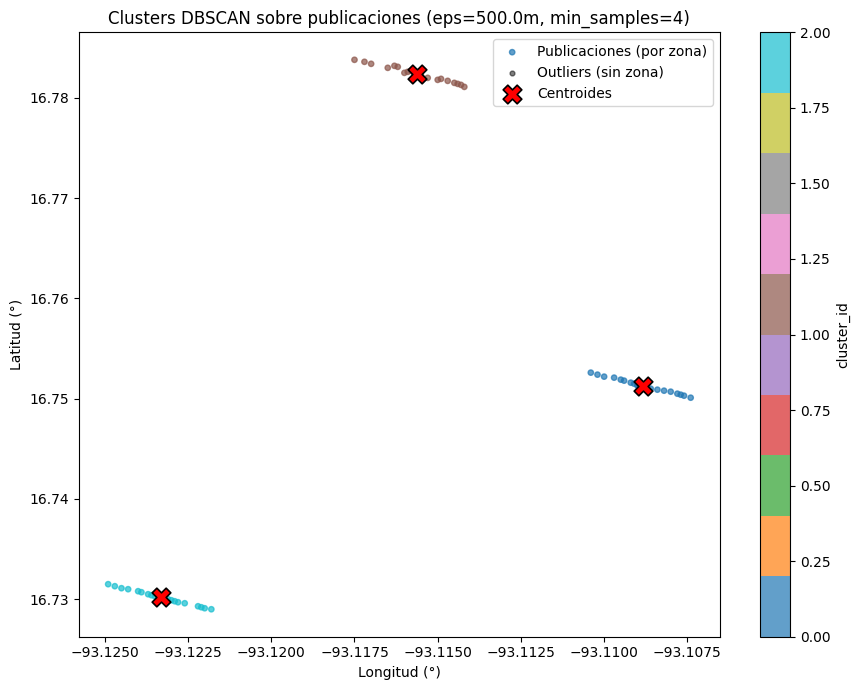

Figura guardada en: /Users/kev29.06/Documents/Cuatrimestre-9/Mineria/Practicas/EDA/treasureflow-ml/servidor-ml/training/notebooks/figures/clusters_scatter.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 7))

inliers = df[df["cluster_id"] != -1]
outliers = df[df["cluster_id"] == -1]

scatter = ax.scatter(
    inliers["lng"], inliers["lat"],
    c=inliers["cluster_id"], cmap="tab10", s=15, alpha=0.7, label="Publicaciones (por zona)"
)
ax.scatter(
    outliers["lng"], outliers["lat"],
    color="black", marker="o", s=12, alpha=0.5, label="Outliers (sin zona)"
)
ax.scatter(
    centroides_df["centroid_lng"], centroides_df["centroid_lat"],
    color="red", marker="X", s=180, edgecolor="black", linewidth=1.2, label="Centroides", zorder=5
)

ax.set_xlabel("Longitud (°)")
ax.set_ylabel("Latitud (°)")
ax.set_title(f"Clusters DBSCAN sobre publicaciones (eps={ML_EPS_METROS}m, min_samples={ML_MIN_SAMPLES})")
ax.legend(loc="best")
plt.colorbar(scatter, ax=ax, label="cluster_id")
plt.tight_layout()

ruta_fig1 = FIGURES_DIR / "clusters_scatter.png"
plt.savefig(ruta_fig1, dpi=150)
plt.show()
print(f"Figura guardada en: {ruta_fig1}")

## 9. Visualización secundaria: resumen de métricas

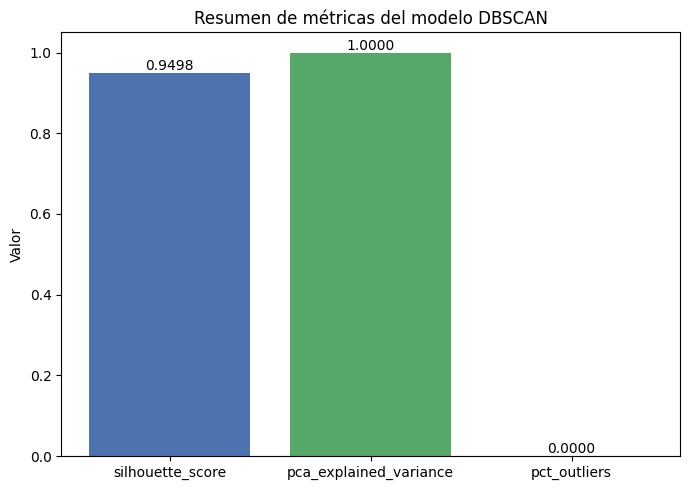

Figura guardada en: /Users/kev29.06/Documents/Cuatrimestre-9/Mineria/Practicas/EDA/treasureflow-ml/servidor-ml/training/notebooks/figures/metricas_resumen.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

nombres = ["silhouette_score", "pca_explained_variance", "pct_outliers"]
valores = [metricas["silhouette_score"], metricas["pca_explained_variance"], metricas["pct_outliers"]]
colores = ["#4C72B0", "#55A868", "#C44E52"]

bars = ax.bar(nombres, valores, color=colores)
ax.set_ylabel("Valor")
ax.set_title("Resumen de métricas del modelo DBSCAN")
ax.axhline(0, color="gray", linewidth=0.8)

for bar, valor in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, valor, f"{valor:.4f}", ha="center",
             va="bottom" if valor >= 0 else "top")

plt.tight_layout()

ruta_fig2 = FIGURES_DIR / "metricas_resumen.png"
plt.savefig(ruta_fig2, dpi=150)
plt.show()
print(f"Figura guardada en: {ruta_fig2}")

## 10. Serialización de artefactos

En producción, `scaler` y `pca` se serializan con `pickle` y se almacenan como `BYTEA`
directamente en la tabla `model_versions` (ver `training/pca_analysis.py:serializar()` y
`training/register.py`). Para este notebook (evidencia de reporte) se guardan como archivos
`.pkl` en disco en su lugar.

In [16]:
ruta_scaler = ARTIFACTS_DIR / "scaler_v1.0.pkl"
ruta_pca = ARTIFACTS_DIR / "pca_v1.0.pkl"

with open(ruta_scaler, "wb") as f:
    pickle.dump(scaler, f)

with open(ruta_pca, "wb") as f:
    pickle.dump(pca, f)

print("Artefactos guardados:")
print(f"  - scaler: {ruta_scaler}")
print(f"  - pca:    {ruta_pca}")

Artefactos guardados:
  - scaler: /Users/kev29.06/Documents/Cuatrimestre-9/Mineria/Practicas/EDA/treasureflow-ml/servidor-ml/training/notebooks/artifacts/scaler_v1.0.pkl
  - pca:    /Users/kev29.06/Documents/Cuatrimestre-9/Mineria/Practicas/EDA/treasureflow-ml/servidor-ml/training/notebooks/artifacts/pca_v1.0.pkl


## 11. Simulación de inferencia

Se replica literalmente `haversine_meters()` de `servidor-ml/inference/predict.py` para
garantizar consistencia exacta con la lógica de inferencia real. Se prueban 5 coordenadas:
3 cercanas a centroides ya detectados (deberían asignarse a una zona) y 2 alejadas de todos
los centroides (deberían quedar como outliers, sin zona asignada).

In [17]:
_EARTH_RADIUS_M = 6_371_000


def haversine_meters(lat1: float, lng1: float, lat2: float, lng2: float) -> float:
    """Distancia en metros entre dos puntos en grados decimales (idéntica a inference/predict.py)."""
    lat1_r, lng1_r = radians(lat1), radians(lng1)
    lat2_r, lng2_r = radians(lat2), radians(lng2)
    dlat = lat2_r - lat1_r
    dlng = lng2_r - lng1_r
    a = sin(dlat / 2) ** 2 + cos(lat1_r) * cos(lat2_r) * sin(dlng / 2) ** 2
    return _EARTH_RADIUS_M * 2 * atan2(sqrt(a), sqrt(1 - a))


def asignar_zona(lat: float, lng: float) -> dict:
    """Réplica de inference/predict.py:assign_zone() usando los centroides calculados arriba."""
    distancias = [
        {
            "zone_id": int(row.zone_id),
            "distance": haversine_meters(lat, lng, float(row.centroid_lat), float(row.centroid_lng)),
        }
        for row in centroides_df.itertuples()
    ]
    mas_cercano = min(distancias, key=lambda x: x["distance"])
    asignado = mas_cercano["distance"] <= ML_EPS_METROS
    return {
        "zone_id": mas_cercano["zone_id"] if asignado else None,
        "distancia_m": round(mas_cercano["distance"], 2),
        "asignado": asignado,
    }

In [18]:
# 3 coordenadas cercanas a centroides existentes (pequeño offset, deberían caer dentro de eps)
# y 2 coordenadas alejadas (deberían quedar fuera de eps -> outliers).
OFFSET_CERCANO = 0.0003  # ~30 metros aproximadamente
OFFSET_LEJANO = 0.2      # ~20 km aproximadamente, garantiza quedar fuera de eps=500m

coords_prueba = []
for row in centroides_df.head(3).itertuples():
    coords_prueba.append((row.centroid_lat + OFFSET_CERCANO, row.centroid_lng + OFFSET_CERCANO))

base_lat, base_lng = float(df["lat"].iloc[0]), float(df["lng"].iloc[0])
coords_prueba.append((base_lat + OFFSET_LEJANO, base_lng + OFFSET_LEJANO))
coords_prueba.append((base_lat - OFFSET_LEJANO, base_lng - OFFSET_LEJANO))

resultados_inferencia = []
for lat_test, lng_test in coords_prueba:
    resultado = asignar_zona(lat_test, lng_test)
    resultados_inferencia.append({"lat": lat_test, "lng": lng_test, **resultado})

inferencia_df = pd.DataFrame(resultados_inferencia)
inferencia_df

,lat,lng,zone_id,distancia_m,asignado
0,16.751590,-93.108545,0.0,46.19,True
1,16.782675,-93.115325,1.0,46.18,True
2,16.730475,-93.123015,2.0,46.19,True
3,16.951200,-92.908900,NaN,28919.10,False
4,16.551200,-93.308900,NaN,28053.17,False


## 12. Resumen ejecutivo final

Tabla con los valores finales del entrenamiento, lista para copiar al reporte.

In [19]:
resumen_final = {
    "silhouette_score": metricas["silhouette_score"],
    "pca_explained_variance": metricas["pca_explained_variance"],
    "n_zones": metricas["n_zones"],
    "pct_outliers": metricas["pct_outliers"],
    "n_training_points": metricas["n_training_points"],
    "eps_metros": ML_EPS_METROS,
    "min_samples": ML_MIN_SAMPLES,
    "fecha_ejecucion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

pd.DataFrame([resumen_final]).T.rename(columns={0: "valor"})

,valor
silhouette_score,0.949789
pca_explained_variance,1.0
n_zones,3
pct_outliers,0.0
n_training_points,60
eps_metros,500.0
min_samples,4
fecha_ejecucion,2026-06-28 22:15:35


### Resumen ejecutivo

| Métrica | Valor |
|---|---|
| silhouette_score | 0.949789 |
| pca_explained_variance | 1.0 |
| n_zones | 3 |
| pct_outliers | 0.0 |
| n_training_points | 60 |
| eps_metros | 500.0 |
| min_samples | 4 |
| fecha_ejecucion | 2026-06-28 22:15:35 |
